<a href="https://colab.research.google.com/github/Dessoka/Assignment-11-I-C/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup: imports and Colab configuration. Imports the libraries i need.

Configures Jupyter/Colab to display tables and plots nicely.

Data Collection – Load the CSV files. Reads both CSVs into Pandas DataFrames.

In [33]:
# ============================
# Cell 0: Imports and settings
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This makes plots show up in the notebook
%matplotlib inline

# Optional: make pandas show more columns
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


Data Collection – Load the CSV files

In [34]:
# =======================================
# Cell 1: Load the datasets from CSV files
# =======================================

# Adjust the filenames here if your file names differ
stocks_path = "Historical stocks.csv"
prices_path = "historical_blocks_prices.csv"

# Load into DataFrames
df_stocks = pd.read_csv(stocks_path)
df_prices = pd.read_csv(prices_path)

# Quick preview
print("STOCKS DATA (metadata) - first 5 rows:")
display(df_stocks.head())

print("\nPRICES DATA - first 5 rows:")
display(df_prices.head())

print("\nStocks info:")
df_stocks.info()

print("\nPrices info:")
df_prices.info()


STOCKS DATA (metadata) - first 5 rows:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS



PRICES DATA - first 5 rows:


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,5/8/2013
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,5/9/2013
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,5/10/2013
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,5/13/2013
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,5/14/2013



Stocks info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB

Prices info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   ticker     1048575 non-null  object 
 1   open       1048575 non-null  float64
 2   close      1048575 non-null  float64
 3   adj_close  1048575 non-null  float64
 4   low        1048575 non-null  float64
 5   high       1048575 non-null  float64
 6   volume     1048575 non-null  int64  
 7   date       1048575 non-null  object 
dtypes: float64(5), int64(

Data Cleaning
2.1 Handle missing values

First, inspect missing values:

In [35]:
# ===========================================
# Cell 2: Check missing values in both datasets
# ===========================================

print("Missing values in STOCKS DATA:")
print(df_stocks.isna().sum())

print("\nMissing values in PRICES DATA:")
print(df_prices.isna().sum())


Missing values in STOCKS DATA:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing values in PRICES DATA:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [36]:
# =====================================================
# Cell 3: Simple missing value treatment / cleaning
# =====================================================

# 1) Drop rows in stocks where ticker is missing (key field)
df_stocks_clean = df_stocks.dropna(subset=["ticker"])

# 2) For prices, we also require ticker and date
# Replace 'date' with your actual column name if needed (e.g., 'Date')
date_col = "date" if "date" in df_prices.columns else "Date"
df_prices_clean = df_prices.dropna(subset=["ticker", date_col])

# For the price numeric columns: Open, High, Low, Close, Volume, Adj Close
# Adjust names depending on your actual columns
numeric_cols = []
for c in df_prices_clean.columns:
    if c.lower() in ["open", "high", "low", "close", "volume", "adj close", "adj_close", "adjusted_close"]:
        numeric_cols.append(c)

print("Numeric columns detected in prices:", numeric_cols)

# Option 1 (simple): Drop rows where any of these numeric columns are missing
df_prices_clean = df_prices_clean.dropna(subset=numeric_cols)

# Reset index after drops
df_stocks_clean = df_stocks_clean.reset_index(drop=True)
df_prices_clean = df_prices_clean.reset_index(drop=True)

print("Shapes after cleaning:")
print("Stocks:", df_stocks_clean.shape)
print("Prices:", df_prices_clean.shape)


Numeric columns detected in prices: ['open', 'close', 'adj_close', 'low', 'high', 'volume']
Shapes after cleaning:
Stocks: (6460, 5)
Prices: (1048575, 8)


Remove duplicate rows

In [37]:
# ==================================
# Cell 4: Remove duplicate rows
# ==================================

print("Duplicates in stocks:", df_stocks_clean.duplicated().sum())
print("Duplicates in prices:", df_prices_clean.duplicated().sum())

df_stocks_clean = df_stocks_clean.drop_duplicates()
df_prices_clean = df_prices_clean.drop_duplicates()

print("After dropping duplicates:")
print("Stocks:", df_stocks_clean.shape)
print("Prices:", df_prices_clean.shape)


Duplicates in stocks: 0
Duplicates in prices: 0
After dropping duplicates:
Stocks: (6460, 5)
Prices: (1048575, 8)


Convert Date to datetime and set as index

In [38]:
# ==============================================
# Cell 5: Convert Date column and set as index
# ==============================================

# Use the previously detected date_col ('date' or 'Date')
df_prices_clean[date_col] = pd.to_datetime(df_prices_clean[date_col])

# Sort by date just to be safe
df_prices_clean = df_prices_clean.sort_values(by=[date_col])

# Set the date column as index
df_prices_clean = df_prices_clean.set_index(date_col)

# Check result
df_prices_clean.head()


,ticker,open,close,adj_close,low,high,volume
date,,,,,,,
1972-06-01,PFE,0.846354,0.859375,0.000628,0.846354,0.859375,2332800
1972-06-02,PFE,0.859375,0.848958,0.000620,0.846354,0.861979,1531200
1972-06-05,PFE,0.848958,0.846354,0.000618,0.841146,0.851562,2452800
1972-06-06,PFE,0.846354,0.864583,0.000631,0.843750,0.869792,2227200
1972-06-07,PFE,0.864583,0.864583,0.000631,0.851562,0.864583,979200


Data Segmentation by Decade
3.1 Create a decade column

We’ll extract the year from the datetime index and then compute the decade.

In [39]:
# ===========================================
# Cell 6: Add a decade column to prices data
# ===========================================

# Create a 'year' column from the index
df_prices_clean["year"] = df_prices_clean.index.year

# Function to convert year to a decade label, e.g. '1970s'
def year_to_decade(y):
    return f"{int(y // 10) * 10}s"

df_prices_clean["decade"] = df_prices_clean["year"].apply(year_to_decade)

df_prices_clean[["year", "decade"]].head()


,year,decade
date,,
1972-06-01,1972,1970s
1972-06-02,1972,1970s
1972-06-05,1972,1970s
1972-06-06,1972,1970s
1972-06-07,1972,1970s


In [40]:
# ===============================================
# Cell 7: Create separate DataFrames per decade
# ===============================================

decades = df_prices_clean["decade"].unique()
decades = sorted(decades)  # sort for consistency

decade_dfs = {}  # dictionary: key = decade string, value = DataFrame

for d in decades:
    subset = df_prices_clean[df_prices_clean["decade"] == d].copy()
    decade_dfs[d] = subset
    print(d, "rows:", subset.shape[0])


1970s rows: 4178
1980s rows: 73215
1990s rows: 165389
2000s rows: 324541
2010s rows: 481252


Merge prices with stocks to add sector info

In [41]:
# ==================================================
# Cell 8: Merge prices with stock metadata (sector)
# ==================================================

# Ensure ticker columns are consistent (strip spaces, uppercase, etc.)
df_stocks_clean["ticker"] = df_stocks_clean["ticker"].str.strip().str.upper()
df_prices_clean["ticker"] = df_prices_clean["ticker"].str.strip().str.upper()

# Merge on 'ticker' - left join on prices to keep all price records
df_merged = df_prices_clean.merge(
    df_stocks_clean,
    on="ticker",
    how="left",
    suffixes=("_price", "_stock")
)

print("Merged DataFrame shape:", df_merged.shape)
df_merged.head()


Merged DataFrame shape: (1048575, 13)


,ticker,open,close,adj_close,low,high,volume,year,decade,exchange,name,sector,industry
0,PFE,0.846354,0.859375,0.000628,0.846354,0.859375,2332800,1972,1970s,NYSE,"PFIZER, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS
1,PFE,0.859375,0.848958,0.000620,0.846354,0.861979,1531200,1972,1970s,NYSE,"PFIZER, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS
2,PFE,0.848958,0.846354,0.000618,0.841146,0.851562,2452800,1972,1970s,NYSE,"PFIZER, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS
3,PFE,0.846354,0.864583,0.000631,0.843750,0.869792,2227200,1972,1970s,NYSE,"PFIZER, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS
4,PFE,0.864583,0.864583,0.000631,0.851562,0.864583,979200,1972,1970s,NYSE,"PFIZER, INC.",HEALTH CARE,MAJOR PHARMACEUTICALS


In [42]:
# ==============================================
# Cell 9: Decade-specific merged DataFrames
# ==============================================

merged_decade_dfs = {}
for d in decades:
    merged_decade_dfs[d] = df_merged[df_merged["decade"] == d].copy()
    print(d, "rows in merged:", merged_decade_dfs[d].shape[0])


1970s rows in merged: 4178
1980s rows in merged: 73215
1990s rows in merged: 165389
2000s rows in merged: 324541
2010s rows in merged: 481252


Exploratory Data Analysis (EDA) by decade
5.1 Summary statistics (mean, median, std) per decade

We’ll compute these for Open, High, Low, Close, Volume.

In [43]:
# ====================================================
# Cell 10: Define the price columns for statistics
# ====================================================

price_cols = []
for c in df_merged.columns:
    c_lower = c.lower()
    if c_lower in ["open", "high", "low", "close", "volume"]:
        price_cols.append(c)

print("Price columns used for summary stats:", price_cols)


Price columns used for summary stats: ['open', 'close', 'low', 'high', 'volume']


In [44]:
# ============================================================
# Cell 11: Summary statistics (mean, median, std) by decade
# ============================================================

summary_stats = {}

for d in decades:
    sub = merged_decade_dfs[d]
    desc = sub[price_cols].agg(["mean", "median", "std"])
    summary_stats[d] = desc
    print(f"\n===== {d} =====")
    display(desc)



===== 1970s =====


,open,close,low,high,volume
mean,0.642189,0.641670,0.633538,0.658042,1.375922e+06
median,0.619792,0.619792,0.609375,0.630208,5.308430e+05
std,0.287365,0.287178,0.284491,0.294714,1.860238e+06



===== 1980s =====


,open,close,low,high,volume
mean,9.780785,9.780221,9.658287,9.920100,1.738268e+06
median,4.015625,4.000000,4.000000,4.083333,5.000000e+04
std,17.851407,17.854036,17.594968,18.090022,9.508968e+06



===== 1990s =====


,open,close,low,high,volume
mean,32.628692,32.546103,31.594542,33.616130,1.852963e+06
median,9.750000,9.750000,9.604167,9.875000,5.680000e+04
std,366.306260,352.473277,328.287222,412.803276,1.343211e+07



===== 2000s =====


,open,close,low,high,volume
mean,132.814041,134.668547,127.397118,139.979761,3.413860e+06
median,14.910000,14.910000,14.680000,15.120000,1.246000e+05
std,5181.753576,5424.959503,4943.471492,5658.625488,2.056548e+07



===== 2010s =====


,open,close,low,high,volume
mean,30.523207,30.522225,30.138984,30.893268,1.604538e+06
median,18.940001,18.940001,18.670000,19.200001,1.333000e+05
std,44.624808,44.617610,44.004589,45.232982,8.727724e+06


Time series plots: average monthly Close price per decade

/tmp/ipython-input-3937476638.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sub[close_col].resample("M").mean()


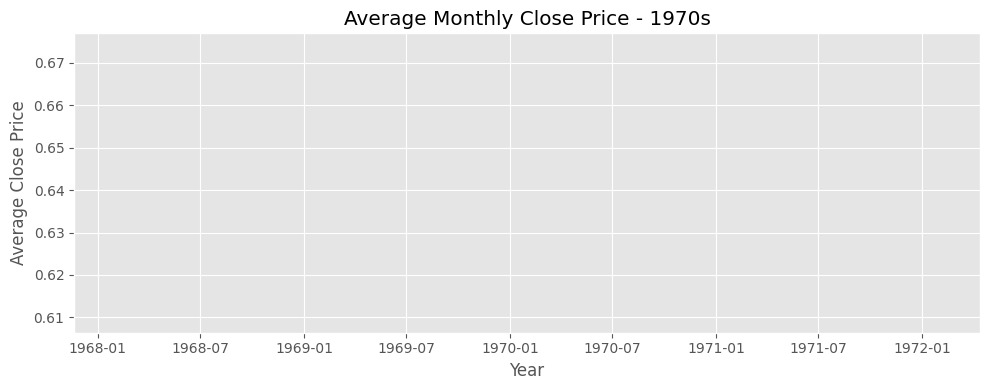

/tmp/ipython-input-3937476638.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sub[close_col].resample("M").mean()


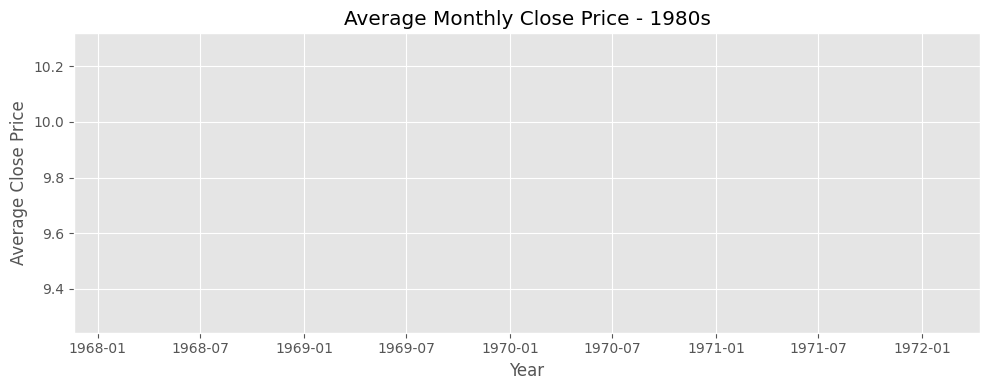

/tmp/ipython-input-3937476638.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sub[close_col].resample("M").mean()


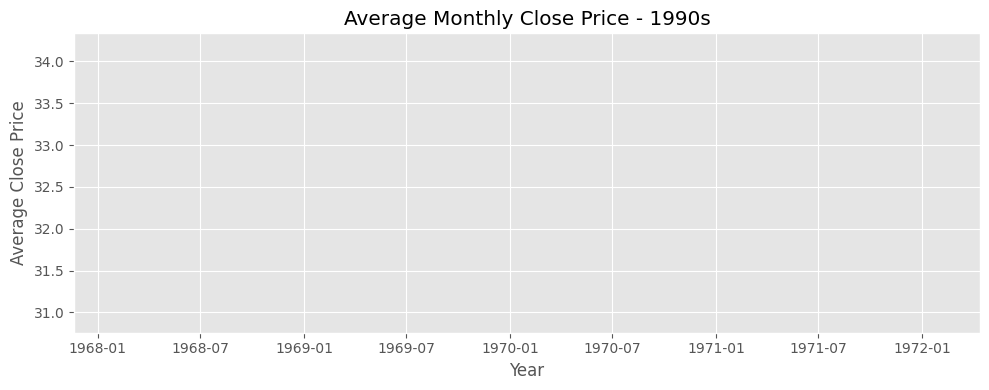

/tmp/ipython-input-3937476638.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sub[close_col].resample("M").mean()


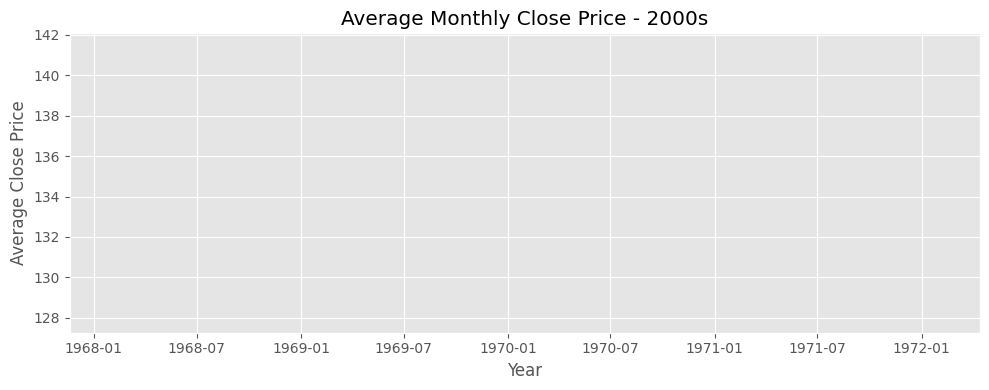

/tmp/ipython-input-3937476638.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sub[close_col].resample("M").mean()


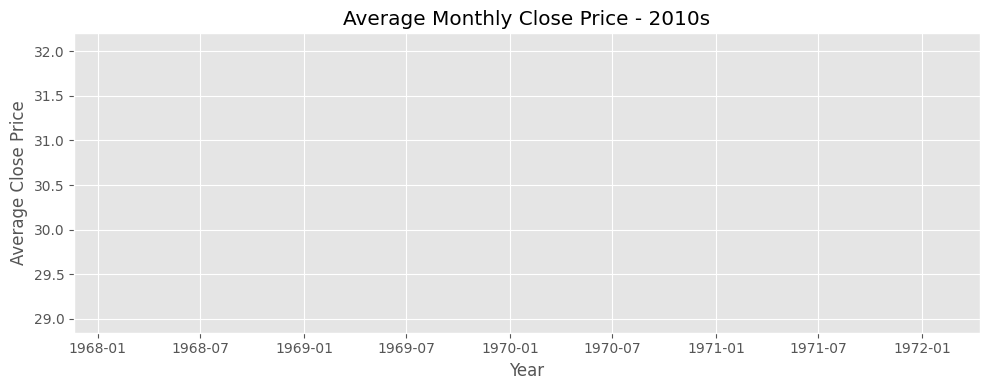

In [47]:
# ----- FIXED 5.2: Time series plots -----

close_col = "close"  # your column is lowercase

for d in decades:
    sub = merged_decade_dfs[d].copy()

    # Ensure the index is datetime (critical fix)
    sub.index = pd.to_datetime(sub.index, errors="coerce")

    # Now resample using the datetime index
    monthly = sub[close_col].resample("M").mean()

    plt.figure(figsize=(10,4))
    plt.plot(monthly.index, monthly.values)
    plt.title(f"Average Monthly Close Price - {d}")
    plt.xlabel("Year")
    plt.ylabel("Average Close Price")
    plt.tight_layout()
    plt.show()


Histograms: Volume distribution per decade

Using Volume column: volume


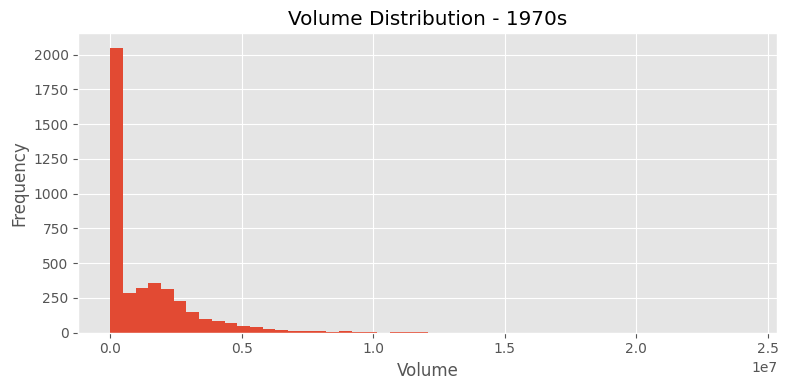

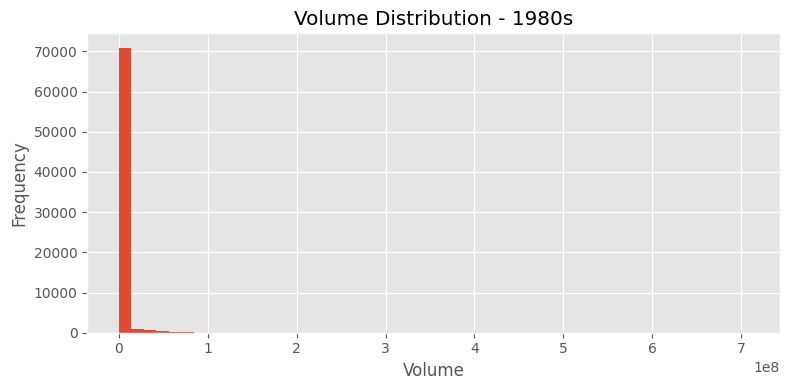

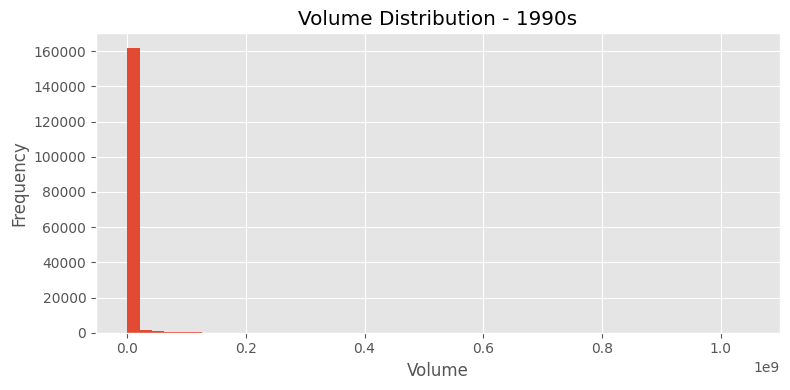

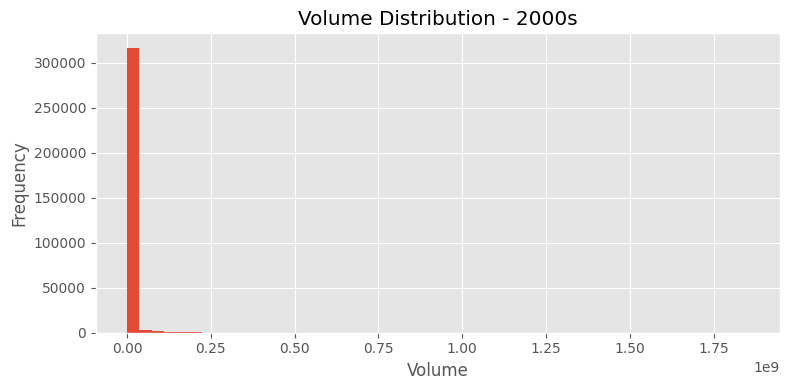

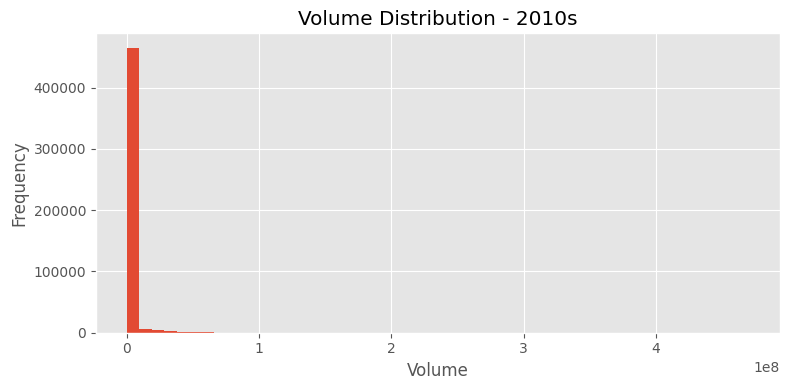

In [48]:
# =====================================================
# Cell 13: Histograms of Volume for each decade
# =====================================================

# Find volume column
volume_col = None
for c in df_merged.columns:
    if c.lower() == "volume":
        volume_col = c
        break

print("Using Volume column:", volume_col)

for d in decades:
    sub = merged_decade_dfs[d]

    plt.figure(figsize=(8, 4))
    plt.hist(sub[volume_col].dropna(), bins=50)
    plt.title(f"Volume Distribution - {d}")
    plt.xlabel("Volume")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


ox plots: High and Low prices per decade (range & outliers)

We’ll create a summary DataFrame with decade, High, Low and make boxplots.

High column: high  | Low column: low


/tmp/ipython-input-142691318.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(high_data, labels=labels, showfliers=True)


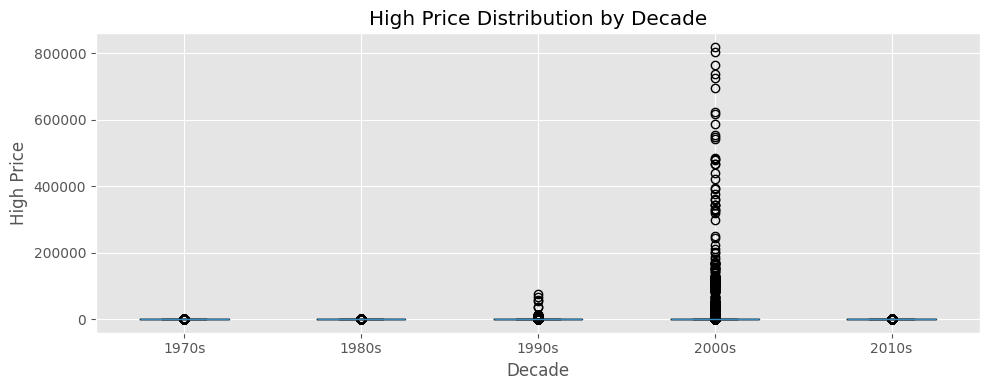

/tmp/ipython-input-142691318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(low_data, labels=labels, showfliers=True)


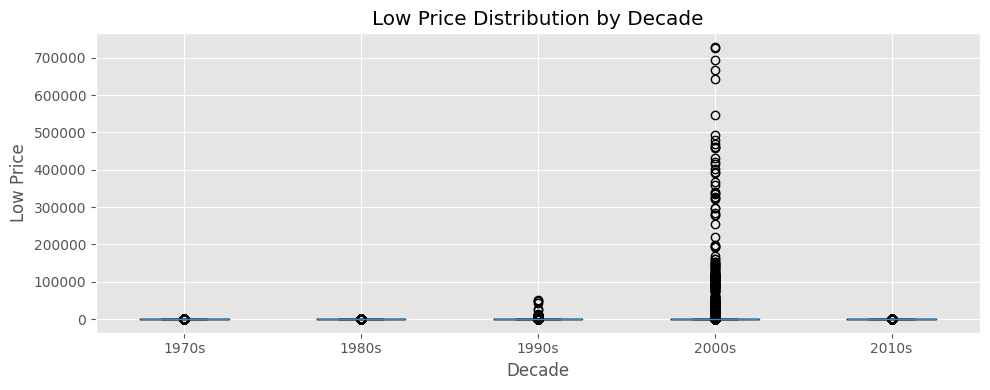

In [49]:
# =========================================================
# Cell 14: Box plots of High and Low prices by decade
# =========================================================

# Find High and Low column names
high_col = None
low_col = None
for c in df_merged.columns:
    if c.lower() == "high":
        high_col = c
    elif c.lower() == "low":
        low_col = c

print("High column:", high_col, " | Low column:", low_col)

# Prepare data for boxplots
high_data = []
low_data = []
labels = []

for d in decades:
    sub = merged_decade_dfs[d]
    high_data.append(sub[high_col].dropna())
    low_data.append(sub[low_col].dropna())
    labels.append(d)

# Boxplot for High
plt.figure(figsize=(10, 4))
plt.boxplot(high_data, labels=labels, showfliers=True)
plt.title("High Price Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("High Price")
plt.tight_layout()
plt.show()

# Boxplot for Low
plt.figure(figsize=(10, 4))
plt.boxplot(low_data, labels=labels, showfliers=True)
plt.title("Low Price Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Low Price")
plt.tight_layout()
plt.show()


. Comparative Analysis (across decades)

You already computed summary stats in summary_stats.
Let’s put some of them into a single table for easier comparison.

For example, compare mean Close and mean Volume per decade:

In [50]:
# ==========================================================
# Cell 15: Comparative statistics across decades
# ==========================================================

comparison_rows = []

for d in decades:
    sub = merged_decade_dfs[d]
    row = {"decade": d}
    # Mean close and volume
    row["mean_close"] = sub[close_col].mean()
    row["median_close"] = sub[close_col].median()
    row["std_close"] = sub[close_col].std()

    row["mean_volume"] = sub[volume_col].mean()
    row["median_volume"] = sub[volume_col].median()
    row["std_volume"] = sub[volume_col].std()

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("decade")
display(comparison_df)


,mean_close,median_close,std_close,mean_volume,median_volume,std_volume
decade,,,,,,
1970s,0.641670,0.619792,0.287178,1.375922e+06,530843.0,1.860238e+06
1980s,9.780221,4.000000,17.854036,1.738268e+06,50000.0,9.508968e+06
1990s,32.546103,9.750000,352.473277,1.852963e+06,56800.0,1.343211e+07
2000s,134.668547,14.910000,5424.959503,3.413860e+06,124600.0,2.056548e+07
2010s,30.522225,18.940001,44.617610,1.604538e+06,133300.0,8.727724e+06


Saving cleaned / merged data

In [52]:
# ===============================================
# Cell 16: Save cleaned and merged dataset to CSV
# ===============================================

df_merged.to_csv("cleaned_merged_stock_data.csv")
print("Saved 'cleaned_merged_stock_data.csv' in the current directory.")


Saved 'cleaned_merged_stock_data.csv' in the current directory.
